In [16]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder,StandardScaler# for ordinal to categorical data, StandardScaler # for feature scaling mean =0,var=1
from sklearn.impute import SimpleImputer # to apply different strategy on different column(min,mean,knn)

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier # multivariant - handle with the help of other col also
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Model selection
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import accuracy_score, mean_squared_error,classification_report


In [2]:
df = pd.read_csv("MOCK_DATA.csv")
df.head()

,room_id,hour,day_of_week,is_weekend,month,lecture_scheduled,exam_period,is_holiday,timetable_strength,previous_occupancy,...,preferred_temperature,manual_override,previous_ac_status,previous_fan_speed,previous_light_status,occupancy,ac_status,fan_speed,light_status,set_temperature
0,1,17,Friday,True,December,11/3/2022,True,False,9,53,...,23,True,Off,Low,On,8,Off,Medium,On,18
1,2,11,Saturday,True,February,11/3/2022,True,False,8,46,...,23,False,On,Medium,Off,69,Off,Medium,Off,23
2,3,16,Friday,True,May,5/14/2022,True,True,9,71,...,28,True,On,High,Off,91,Off,Medium,Off,20
3,4,12,Tuesday,True,June,4/17/2022,True,False,3,77,...,19,False,On,Medium,On,87,Off,High,On,20
4,5,0,Friday,False,October,8/25/2022,True,True,8,19,...,28,False,On,Medium,On,86,On,Medium,On,30


In [7]:
# handle missing values
imputer = SimpleImputer(strategy='mean')
df[df.select_dtypes(include=np.number).columns] = imputer.fit_transform(
    df.select_dtypes(include=np.number)
)

In [9]:
# feature engineering

# Existing Features
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 9 <= x <= 17 else 0)

df['temp_diff'] = df['outside_temperature'] - df['preferred_temperature']

df['energy_score'] = (
    df['previous_ac_status']*2 +
    df['previous_fan_speed'] +
    df['previous_light_status']
)

# NEW FEATURES

# Office working hours
df['office_hour'] = df['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

# Night time detection
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)

# Temperature comfort gap
df['comfort_gap'] = abs(
    df['outside_temperature'] - df['preferred_temperature']
)

# Previous device usage intensity
df['usage_intensity'] = (
    df['previous_ac_status'] +
    df['previous_fan_speed'] +
    df['previous_light_status']
)


df['previous_occupancy'] = pd.to_numeric(df['previous_occupancy'], errors='coerce').fillna(0)
df['lecture_scheduled'] = pd.to_numeric(df['lecture_scheduled'], errors='coerce').fillna(0)

df['occupancy_trend'] = (
    df['previous_occupancy'] *
    df['lecture_scheduled']
)

In [23]:
# encode categorical data
le = LabelEncoder()
df['weather_condition'] = le.fit_transform(df['weather_condition'])

In [24]:
# Outlier detection


# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1 #Intraquantile range

# Filter out outliers
filtered_df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
                   (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [12]:
# Feature Selection
features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'month',
    'lecture_scheduled',
    'exam_period',
    'is_holiday',
    'timetable_strength',
    'previous_occupancy',
    'outside_temperature',
    'weather_condition',
    'preferred_temperature',
    'manual_override',
    'previous_ac_status',
    'previous_fan_speed',
    'previous_light_status',
    'is_peak_hour',
    'temp_diff',
    'energy_score',

    # NEW FEATURES
    'office_hour',
    'is_night',
    'comfort_gap',
    'usage_intensity',
    'occupancy_trend'
]

X = df[features]

# Targets (INTEGRATED SYSTEM)
y_class = df[['ac_status','fan_speed','light_status']]

# Regression target
y_reg = df['set_temperature']

In [13]:
# Encode
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Recreate features
X = df[features]

# Ensure numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Scale
X_scaled = StandardScaler().fit_transform(X)

In [14]:
# Train-Test-Split
X_train, X_test, y_train_class, y_test_class = train_test_split(
    X_scaled,
    y_class,
    test_size=0.2,
    random_state=42
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [17]:
# Random Forest (Separate Models)

# AC MODEL
rf_ac = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_ac.fit(X_train, y_train_class['ac_status'])

pred_ac = rf_ac.predict(X_test)

print("AC Accuracy:",
      accuracy_score(y_test_class['ac_status'], pred_ac))

print(classification_report(
    y_test_class['ac_status'],
    pred_ac
))


# FAN MODEL
rf_fan = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_fan.fit(X_train, y_train_class['fan_speed'])

pred_fan = rf_fan.predict(X_test)

print("Fan Accuracy:",
      accuracy_score(y_test_class['fan_speed'], pred_fan))

print(classification_report(
    y_test_class['fan_speed'],
    pred_fan
))


# LIGHT MODEL
rf_light = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_light.fit(X_train, y_train_class['light_status'])

pred_light = rf_light.predict(X_test)

print("Light Accuracy:",
      accuracy_score(y_test_class['light_status'], pred_light))

print(classification_report(
    y_test_class['light_status'],
    pred_light
))

AC Accuracy: 0.47
              precision    recall  f1-score   support

         Off       0.42      0.53      0.47        89
          On       0.53      0.42      0.47       111

    accuracy                           0.47       200
   macro avg       0.48      0.48      0.47       200
weighted avg       0.48      0.47      0.47       200

Fan Accuracy: 0.29
              precision    recall  f1-score   support

        High       0.31      0.26      0.28        62
         Low       0.33      0.29      0.31        78
      Medium       0.24      0.32      0.28        60

    accuracy                           0.29       200
   macro avg       0.29      0.29      0.29       200
weighted avg       0.30      0.29      0.29       200

Light Accuracy: 0.485
              precision    recall  f1-score   support

         Off       0.51      0.56      0.53       105
          On       0.45      0.40      0.42        95

    accuracy                           0.48       200
   macro avg   

In [30]:
# Logistic Regression
log_model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
log_model.fit(X_train, y_train_class)

y_pred_log = log_model.predict(X_test)

In [31]:
# KNN
knn_model = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=5))
knn_model.fit(X_train, y_train_class)

y_pred_knn = knn_model.predict(X_test)

In [19]:
# Linear Regression
lin_model = LinearRegression()

lin_model.fit(X_train, y_train_reg)

y_pred_lin = lin_model.predict(X_test)

print("MSE:", mean_squared_error(y_test_reg, y_pred_lin))

MSE: 20.196954786842404


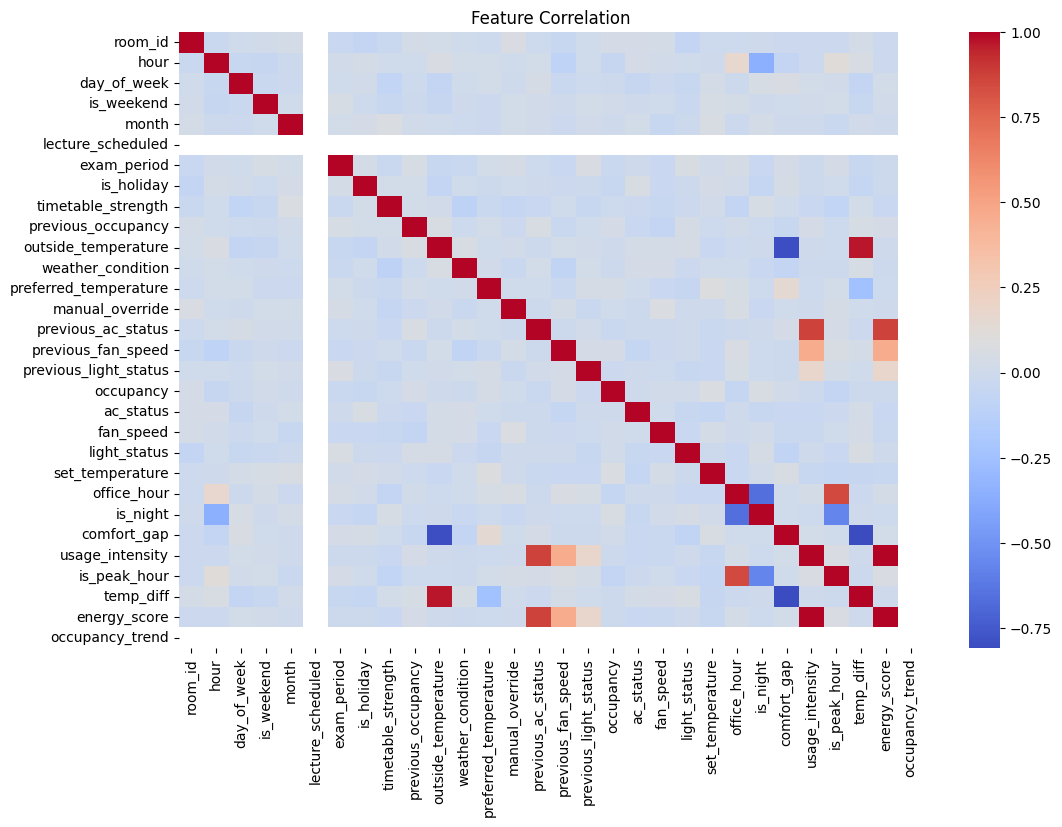

In [20]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

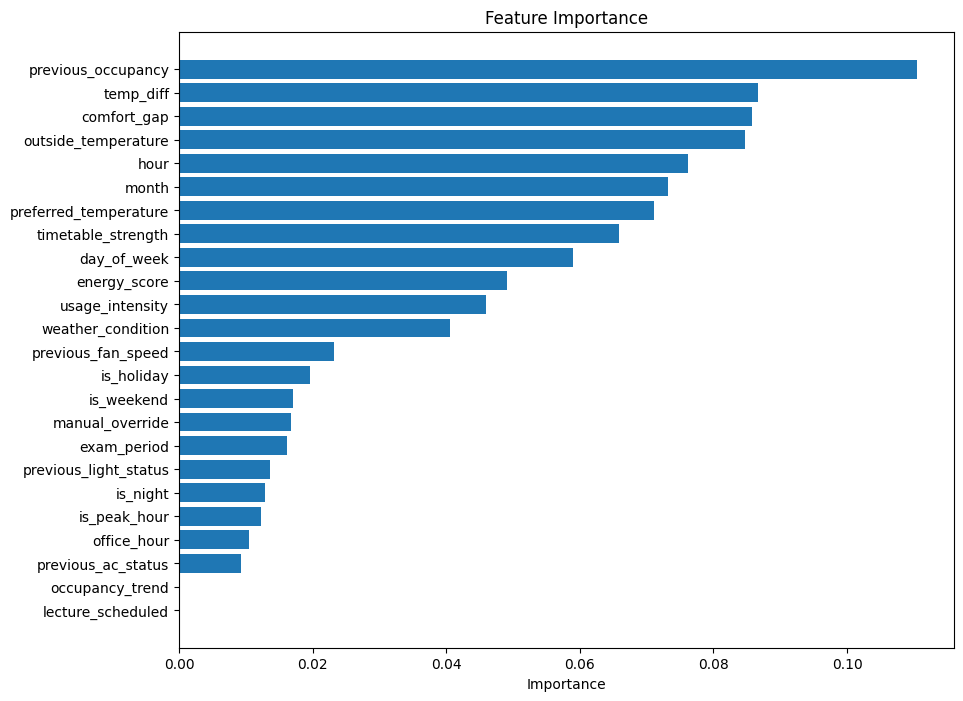

In [22]:
# Feature Importance

importances = rf_ac.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)

plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [23]:
# Final output (for demo)

sample = X_test[0].reshape(1, -1)

pred_ac_demo = rf_ac.predict(sample)
pred_fan_demo = rf_fan.predict(sample)
pred_light_demo = rf_light.predict(sample)

print("Predicted AC Status:", pred_ac_demo[0])
print("Predicted Fan Speed:", pred_fan_demo[0])
print("Predicted Light Status:", pred_light_demo[0])

Predicted AC Status: On
Predicted Fan Speed: Medium
Predicted Light Status: On


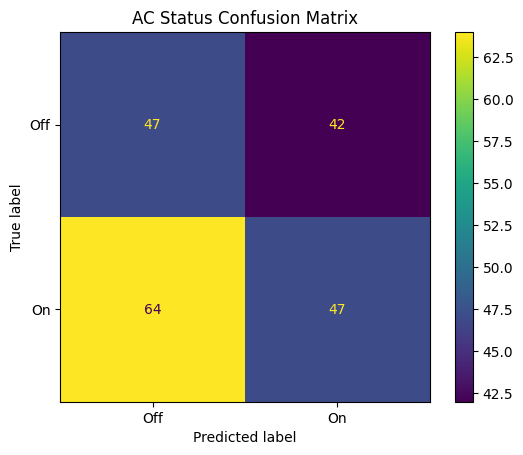

In [24]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_class['ac_status'],
    pred_ac
)

plt.title("AC Status Confusion Matrix")
plt.show()